In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
PROCESSED_DATA_PATH = Path("../data/processed/delhi_traffic_hourly.parquet")

df = pd.read_parquet(PROCESSED_DATA_PATH)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nTimestamp range:")
print(df["timestamp"].min(), "→", df["timestamp"].max())

Shape: (11970240, 11)

Columns:
['date', 'segment_id', 'new_segment_id', 'speed_limit', 'frc', 'street_name', 'distance', 'time_set', 'probe_count', 'hour', 'timestamp']

Timestamp range:
2024-08-11 00:00:00 → 2024-08-30 23:00:00


In [4]:
df = df.sort_values(
    ["segment_id", "timestamp"]
).reset_index(drop=True)

print(df[["segment_id", "timestamp", "probe_count"]].head(20))

        segment_id           timestamp  probe_count
0  -13560345653226 2024-08-11 00:00:00            0
1  -13560345653226 2024-08-11 01:00:00            1
2  -13560345653226 2024-08-11 02:00:00            0
3  -13560345653226 2024-08-11 03:00:00            0
4  -13560345653226 2024-08-11 04:00:00            0
5  -13560345653226 2024-08-11 05:00:00            0
6  -13560345653226 2024-08-11 06:00:00            0
7  -13560345653226 2024-08-11 07:00:00            0
8  -13560345653226 2024-08-11 08:00:00            0
9  -13560345653226 2024-08-11 09:00:00            0
10 -13560345653226 2024-08-11 10:00:00            0
11 -13560345653226 2024-08-11 11:00:00            0
12 -13560345653226 2024-08-11 12:00:00            1
13 -13560345653226 2024-08-11 13:00:00            0
14 -13560345653226 2024-08-11 14:00:00            0
15 -13560345653226 2024-08-11 15:00:00            0
16 -13560345653226 2024-08-11 16:00:00            0
17 -13560345653226 2024-08-11 17:00:00            0
18 -13560345

In [5]:
time_diff = (
    df.groupby("segment_id")["timestamp"]
      .diff()
      .dropna()
)

print(time_diff.value_counts().head())

timestamp
0 days 01:00:00    11945302
Name: count, dtype: int64


In [6]:
print("Unexpected time gaps:")

unexpected_gaps = time_diff[time_diff != pd.Timedelta(hours=1)]

print("Number of unexpected gaps:", len(unexpected_gaps))

if len(unexpected_gaps) > 0:
    print(unexpected_gaps.value_counts().head(20))
else:
    print("No unexpected gaps found.")

Unexpected time gaps:
Number of unexpected gaps: 0
No unexpected gaps found.


In [7]:
lag_features = [1, 2, 3, 6, 24]

for lag in lag_features:
    df[f"probe_lag_{lag}"] = (
        df.groupby("segment_id")["probe_count"]
          .shift(lag)
    )

print(df[
    [
        "segment_id",
        "timestamp",
        "probe_count",
        "probe_lag_1",
        "probe_lag_2",
        "probe_lag_3",
        "probe_lag_6",
        "probe_lag_24"
    ]
].head(30))

        segment_id           timestamp  probe_count  probe_lag_1  probe_lag_2  \
0  -13560345653226 2024-08-11 00:00:00            0          NaN          NaN   
1  -13560345653226 2024-08-11 01:00:00            1          0.0          NaN   
2  -13560345653226 2024-08-11 02:00:00            0          1.0          0.0   
3  -13560345653226 2024-08-11 03:00:00            0          0.0          1.0   
4  -13560345653226 2024-08-11 04:00:00            0          0.0          0.0   
5  -13560345653226 2024-08-11 05:00:00            0          0.0          0.0   
6  -13560345653226 2024-08-11 06:00:00            0          0.0          0.0   
7  -13560345653226 2024-08-11 07:00:00            0          0.0          0.0   
8  -13560345653226 2024-08-11 08:00:00            0          0.0          0.0   
9  -13560345653226 2024-08-11 09:00:00            0          0.0          0.0   
10 -13560345653226 2024-08-11 10:00:00            0          0.0          0.0   
11 -13560345653226 2024-08-1

In [8]:
# Create rolling features strictly within each road segment
df["rolling_mean_3h"] = (
    df.groupby("segment_id")["probe_count"]
      .transform(lambda x: x.shift(1).rolling(window=3).mean())
)

df["rolling_std_3h"] = (
    df.groupby("segment_id")["probe_count"]
      .transform(lambda x: x.shift(1).rolling(window=3).std())
)

df["rolling_mean_6h"] = (
    df.groupby("segment_id")["probe_count"]
      .transform(lambda x: x.shift(1).rolling(window=6).mean())
)

print(
    df[
        [
            "segment_id",
            "timestamp",
            "probe_count",
            "probe_lag_1",
            "rolling_mean_3h",
            "rolling_std_3h",
            "rolling_mean_6h"
        ]
    ].head(35)
)

        segment_id           timestamp  probe_count  probe_lag_1  \
0  -13560345653226 2024-08-11 00:00:00            0          NaN   
1  -13560345653226 2024-08-11 01:00:00            1          0.0   
2  -13560345653226 2024-08-11 02:00:00            0          1.0   
3  -13560345653226 2024-08-11 03:00:00            0          0.0   
4  -13560345653226 2024-08-11 04:00:00            0          0.0   
5  -13560345653226 2024-08-11 05:00:00            0          0.0   
6  -13560345653226 2024-08-11 06:00:00            0          0.0   
7  -13560345653226 2024-08-11 07:00:00            0          0.0   
8  -13560345653226 2024-08-11 08:00:00            0          0.0   
9  -13560345653226 2024-08-11 09:00:00            0          0.0   
10 -13560345653226 2024-08-11 10:00:00            0          0.0   
11 -13560345653226 2024-08-11 11:00:00            0          0.0   
12 -13560345653226 2024-08-11 12:00:00            1          0.0   
13 -13560345653226 2024-08-11 13:00:00          

In [9]:
print(
    df[
        [
            "timestamp",
            "probe_count",
            "rolling_mean_3h",
            "rolling_std_3h",
            "rolling_mean_6h"
        ]
    ].iloc[:10]
)

            timestamp  probe_count  rolling_mean_3h  rolling_std_3h  \
0 2024-08-11 00:00:00            0              NaN             NaN   
1 2024-08-11 01:00:00            1              NaN             NaN   
2 2024-08-11 02:00:00            0              NaN             NaN   
3 2024-08-11 03:00:00            0         0.333333         0.57735   
4 2024-08-11 04:00:00            0         0.333333         0.57735   
5 2024-08-11 05:00:00            0         0.000000         0.00000   
6 2024-08-11 06:00:00            0         0.000000         0.00000   
7 2024-08-11 07:00:00            0         0.000000         0.00000   
8 2024-08-11 08:00:00            0         0.000000         0.00000   
9 2024-08-11 09:00:00            0         0.000000         0.00000   

   rolling_mean_6h  
0              NaN  
1              NaN  
2              NaN  
3              NaN  
4              NaN  
5              NaN  
6         0.166667  
7         0.166667  
8         0.000000  
9       

In [10]:
# Calendar features

df["day_of_week"] = df["timestamp"].dt.dayofweek
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

# Cyclical encoding of hour
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

# Cyclical encoding of day of week
df["day_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["day_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

print(
    df[
        [
            "timestamp",
            "hour",
            "day_of_week",
            "is_weekend",
            "hour_sin",
            "hour_cos",
            "day_sin",
            "day_cos"
        ]
    ].head(10)
)

            timestamp  hour  day_of_week  is_weekend  hour_sin      hour_cos  \
0 2024-08-11 00:00:00     0            6           1  0.000000  1.000000e+00   
1 2024-08-11 01:00:00     1            6           1  0.258819  9.659258e-01   
2 2024-08-11 02:00:00     2            6           1  0.500000  8.660254e-01   
3 2024-08-11 03:00:00     3            6           1  0.707107  7.071068e-01   
4 2024-08-11 04:00:00     4            6           1  0.866025  5.000000e-01   
5 2024-08-11 05:00:00     5            6           1  0.965926  2.588190e-01   
6 2024-08-11 06:00:00     6            6           1  1.000000  6.123234e-17   
7 2024-08-11 07:00:00     7            6           1  0.965926 -2.588190e-01   
8 2024-08-11 08:00:00     8            6           1  0.866025 -5.000000e-01   
9 2024-08-11 09:00:00     9            6           1  0.707107 -7.071068e-01   

    day_sin  day_cos  
0 -0.781831  0.62349  
1 -0.781831  0.62349  
2 -0.781831  0.62349  
3 -0.781831  0.62349  
4 -0

In [11]:
# Create next-hour prediction target

df["target_next_hour"] = (
    df.groupby("segment_id")["probe_count"]
      .shift(-1)
)

print(
    df[
        [
            "segment_id",
            "timestamp",
            "probe_count",
            "target_next_hour"
        ]
    ].head(30)
)

        segment_id           timestamp  probe_count  target_next_hour
0  -13560345653226 2024-08-11 00:00:00            0               1.0
1  -13560345653226 2024-08-11 01:00:00            1               0.0
2  -13560345653226 2024-08-11 02:00:00            0               0.0
3  -13560345653226 2024-08-11 03:00:00            0               0.0
4  -13560345653226 2024-08-11 04:00:00            0               0.0
5  -13560345653226 2024-08-11 05:00:00            0               0.0
6  -13560345653226 2024-08-11 06:00:00            0               0.0
7  -13560345653226 2024-08-11 07:00:00            0               0.0
8  -13560345653226 2024-08-11 08:00:00            0               0.0
9  -13560345653226 2024-08-11 09:00:00            0               0.0
10 -13560345653226 2024-08-11 10:00:00            0               0.0
11 -13560345653226 2024-08-11 11:00:00            0               1.0
12 -13560345653226 2024-08-11 12:00:00            1               0.0
13 -13560345653226 2

In [12]:
print("Target missing values:", df["target_next_hour"].isna().sum())

print("\nLast observations for one road:")
print(
    df[
        [
            "segment_id",
            "timestamp",
            "probe_count",
            "target_next_hour"
        ]
    ].groupby("segment_id")
     .tail(2)
     .head(10)
)

Target missing values: 24938

Last observations for one road:
          segment_id           timestamp  probe_count  target_next_hour
478  -13560345653226 2024-08-30 22:00:00            0               0.0
479  -13560345653226 2024-08-30 23:00:00            0               NaN
958  -13560345653148 2024-08-30 22:00:00            4               1.0
959  -13560345653148 2024-08-30 23:00:00            1               NaN
1438 -13560345652995 2024-08-30 22:00:00           48              38.0
1439 -13560345652995 2024-08-30 23:00:00           38               NaN
1918 -13560345652992 2024-08-30 22:00:00           58              45.0
1919 -13560345652992 2024-08-30 23:00:00           45               NaN
2398 -13560345652964 2024-08-30 22:00:00           99              50.0
2399 -13560345652964 2024-08-30 23:00:00           50               NaN


In [13]:
# Remove rows where the next-hour target is unavailable
df_model = df.dropna(subset=["target_next_hour"]).copy()

print("Original rows:", len(df))
print("Rows after removing missing targets:", len(df_model))
print("Rows removed:", len(df) - len(df_model))

Original rows: 11970240
Rows after removing missing targets: 11945302
Rows removed: 24938


In [14]:
print("Missing target values:", df_model["target_next_hour"].isna().sum())
print("Timestamp range:", df_model["timestamp"].min(), "→", df_model["timestamp"].max())

Missing target values: 0
Timestamp range: 2024-08-11 00:00:00 → 2024-08-30 22:00:00


In [15]:
# Check engineered feature columns

feature_columns = [
    "probe_count",
    "probe_lag_1",
    "probe_lag_2",
    "probe_lag_3",
    "probe_lag_6",
    "probe_lag_24",
    "rolling_mean_3h",
    "rolling_std_3h",
    "rolling_mean_6h",
    "hour",
    "day_of_week",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos",
    "speed_limit",
    "frc",
    "distance"
]

print("Feature availability:\n")
print(df_model[feature_columns].isna().sum())

Feature availability:

probe_count             0
probe_lag_1         24938
probe_lag_2         49876
probe_lag_3         74814
probe_lag_6        149628
probe_lag_24       598512
rolling_mean_3h     74814
rolling_std_3h      74814
rolling_mean_6h    149628
hour                    0
day_of_week             0
is_weekend              0
hour_sin                0
hour_cos                0
day_sin                 0
day_cos                 0
speed_limit             0
frc                     0
distance                0
dtype: int64


In [16]:
print("Feature dataset shape:", df_model.shape)

print("\nTarget statistics:")
print(df_model["target_next_hour"].describe())

print("\nFeature columns:")
for col in feature_columns:
    print("-", col)

Feature dataset shape: (11945302, 26)

Target statistics:
count    1.194530e+07
mean     1.240925e+02
std      1.963573e+02
min      0.000000e+00
25%      9.000000e+00
50%      4.600000e+01
75%      1.480000e+02
max      2.766000e+03
Name: target_next_hour, dtype: float64

Feature columns:
- probe_count
- probe_lag_1
- probe_lag_2
- probe_lag_3
- probe_lag_6
- probe_lag_24
- rolling_mean_3h
- rolling_std_3h
- rolling_mean_6h
- hour
- day_of_week
- is_weekend
- hour_sin
- hour_cos
- day_sin
- day_cos
- speed_limit
- frc
- distance


In [17]:
# Features used for the first forecasting model

feature_columns = [
    "probe_count",
    "probe_lag_1",
    "probe_lag_2",
    "probe_lag_3",
    "probe_lag_6",
    "probe_lag_24",
    "rolling_mean_3h",
    "rolling_std_3h",
    "rolling_mean_6h",
    "hour",
    "day_of_week",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos",
    "speed_limit",
    "frc",
    "distance"
]

target_column = "target_next_hour"

# Keep only rows with complete features and target
df_ml = df_model.dropna(
    subset=feature_columns + [target_column]
).copy()

print("Original modeling rows:", len(df_model))
print("Final ML rows:", len(df_ml))
print("Rows removed:", len(df_model) - len(df_ml))
print("Unique roads:", df_ml["segment_id"].nunique())

Original modeling rows: 11945302
Final ML rows: 11346790
Rows removed: 598512
Unique roads: 24938


In [18]:
print("\nFinal ML dataset:")
print(df_ml[feature_columns + [target_column]].isna().sum())

print("\nTimestamp range:")
print(df_ml["timestamp"].min(), "→", df_ml["timestamp"].max())

print("\nObservations per road:")
print(df_ml.groupby("segment_id").size().describe())


Final ML dataset:
probe_count         0
probe_lag_1         0
probe_lag_2         0
probe_lag_3         0
probe_lag_6         0
probe_lag_24        0
rolling_mean_3h     0
rolling_std_3h      0
rolling_mean_6h     0
hour                0
day_of_week         0
is_weekend          0
hour_sin            0
hour_cos            0
day_sin             0
day_cos             0
speed_limit         0
frc                 0
distance            0
target_next_hour    0
dtype: int64

Timestamp range:
2024-08-12 00:00:00 → 2024-08-30 22:00:00

Observations per road:
count    24938.0
mean       455.0
std          0.0
min        455.0
25%        455.0
50%        455.0
75%        455.0
max        455.0
dtype: float64


In [19]:
# Chronological train / validation / test split

train_end = pd.Timestamp("2024-08-24 23:00:00")
val_end = pd.Timestamp("2024-08-27 23:00:00")

train_df = df_ml[
    df_ml["timestamp"] <= train_end
].copy()

val_df = df_ml[
    (df_ml["timestamp"] > train_end) &
    (df_ml["timestamp"] <= val_end)
].copy()

test_df = df_ml[
    df_ml["timestamp"] > val_end
].copy()

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain range:")
print(train_df["timestamp"].min(), "→", train_df["timestamp"].max())

print("\nValidation range:")
print(val_df["timestamp"].min(), "→", val_df["timestamp"].max())

print("\nTest range:")
print(test_df["timestamp"].min(), "→", test_df["timestamp"].max())

Train shape: (7780656, 26)
Validation shape: (1795536, 26)
Test shape: (1770598, 26)

Train range:
2024-08-12 00:00:00 → 2024-08-24 23:00:00

Validation range:
2024-08-25 00:00:00 → 2024-08-27 23:00:00

Test range:
2024-08-28 00:00:00 → 2024-08-30 22:00:00


In [20]:

print("Chronological check:")

print(
    "Train ends before validation:",
    train_df["timestamp"].max() < val_df["timestamp"].min()
)

print(
    "Validation ends before test:",
    val_df["timestamp"].max() < test_df["timestamp"].min()
)

print("\nRows:")
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))



Chronological check:
Train ends before validation: True
Validation ends before test: True

Rows:
Train: 7780656
Validation: 1795536
Test: 1770598


In [21]:
# Naive baseline: predict next hour = current hour

val_baseline = val_df["probe_count"]
val_actual = val_df["target_next_hour"]

test_baseline = test_df["probe_count"]
test_actual = test_df["target_next_hour"]

print("Validation baseline prepared.")
print("Test baseline prepared.")

Validation baseline prepared.
Test baseline prepared.


In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Validation metrics
val_mae = mean_absolute_error(val_actual, val_baseline)
val_rmse = np.sqrt(mean_squared_error(val_actual, val_baseline))

# Test metrics
test_mae = mean_absolute_error(test_actual, test_baseline)
test_rmse = np.sqrt(mean_squared_error(test_actual, test_baseline))

print("Naive Baseline Performance")
print("-" * 35)

print("\nValidation:")
print("MAE :", round(val_mae, 3))
print("RMSE:", round(val_rmse, 3))

print("\nTest:")
print("MAE :", round(test_mae, 3))
print("RMSE:", round(test_rmse, 3))

Naive Baseline Performance
-----------------------------------

Validation:
MAE : 23.029
RMSE: 45.008

Test:
MAE : 26.432
RMSE: 51.86


In [23]:
# Features for the XGBoost forecasting model

feature_columns = [
    "probe_count",
    "probe_lag_1",
    "probe_lag_2",
    "probe_lag_3",
    "probe_lag_6",
    "probe_lag_24",
    "rolling_mean_3h",
    "rolling_std_3h",
    "rolling_mean_6h",
    "hour",
    "day_of_week",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos",
    "speed_limit",
    "frc",
    "distance"
]

target_column = "target_next_hour"

X_train = train_df[feature_columns]
y_train = train_df[target_column]

X_val = val_df[feature_columns]
y_val = val_df[target_column]

X_test = test_df[feature_columns]
y_test = test_df[target_column]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (7780656, 19)
y_train: (7780656,)
X_val: (1795536, 19)
y_val: (1795536,)
X_test: (1770598, 19)
y_test: (1770598,)


In [24]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [25]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

model.fit(
    
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print("XGBoost training completed.")

XGBoost training completed.


In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

val_pred = model.predict(X_val)
test_pred = model.predict(X_test)

xgb_val_mae = mean_absolute_error(y_val, val_pred)
xgb_val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))

xgb_test_mae = mean_absolute_error(y_test, test_pred)
xgb_test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

print("XGBoost Performance")
print("-" * 35)

print("\nValidation:")
print("MAE :", round(xgb_val_mae, 3))
print("RMSE:", round(xgb_val_rmse, 3))

print("\nTest:")
print("MAE :", round(xgb_test_mae, 3))
print("RMSE:", round(xgb_test_rmse, 3))

XGBoost Performance
-----------------------------------

Validation:
MAE : 17.084
RMSE: 34.212

Test:
MAE : 19.446
RMSE: 38.533


In [27]:
# Feature importance from XGBoost

feature_importance = (
    pd.DataFrame({
        "feature": feature_columns,
        "importance": model.feature_importances_
    })
    .sort_values("importance", ascending=False)
)

print("Feature Importance:")
print(feature_importance)

Feature Importance:
            feature  importance
0       probe_count    0.874241
1       probe_lag_1    0.051988
13         hour_cos    0.017341
12         hour_sin    0.010671
5      probe_lag_24    0.009546
9              hour    0.006679
11       is_weekend    0.003992
17              frc    0.003467
16      speed_limit    0.003155
10      day_of_week    0.002648
15          day_cos    0.002374
14          day_sin    0.002262
6   rolling_mean_3h    0.002068
4       probe_lag_6    0.001992
8   rolling_mean_6h    0.001988
7    rolling_std_3h    0.001792
3       probe_lag_3    0.001656
2       probe_lag_2    0.001374
18         distance    0.000768


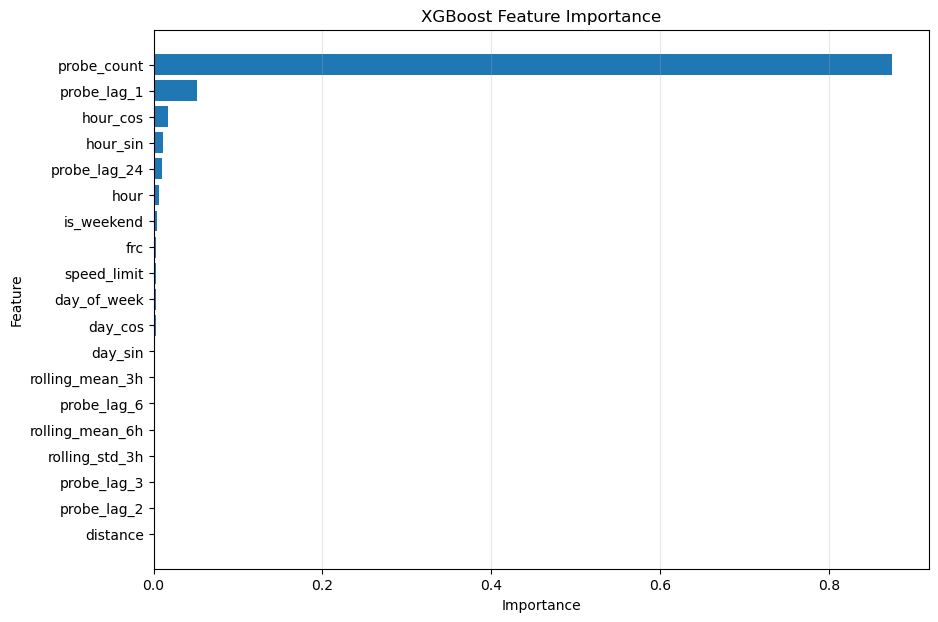

In [28]:
plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)

plt.show()

In [29]:
print("Feature importance sum:", feature_importance["importance"].sum())

print("\nTop 10 features:")
print(feature_importance.head(10))

Feature importance sum: 1.0000001

Top 10 features:
         feature  importance
0    probe_count    0.874241
1    probe_lag_1    0.051988
13      hour_cos    0.017341
12      hour_sin    0.010671
5   probe_lag_24    0.009546
9           hour    0.006679
11    is_weekend    0.003992
17           frc    0.003467
16   speed_limit    0.003155
10   day_of_week    0.002648


In [30]:
print("Training period:")
print(train_df["timestamp"].min(), "→", train_df["timestamp"].max())

print("\nValidation period:")
print(val_df["timestamp"].min(), "→", val_df["timestamp"].max())

print("\nTest period:")
print(test_df["timestamp"].min(), "→", test_df["timestamp"].max())

Training period:
2024-08-12 00:00:00 → 2024-08-24 23:00:00

Validation period:
2024-08-25 00:00:00 → 2024-08-27 23:00:00

Test period:
2024-08-28 00:00:00 → 2024-08-30 22:00:00


In [31]:
# Feature ablation experiment

feature_groups = {
    "Current traffic only": [
        "probe_count"
    ],

    "Traffic history": [
        "probe_count",
        "probe_lag_1",
        "probe_lag_2",
        "probe_lag_3",
        "probe_lag_6",
        "probe_lag_24",
        "rolling_mean_3h",
        "rolling_std_3h",
        "rolling_mean_6h"
    ],

    "Traffic + temporal": [
        "probe_count",
        "probe_lag_1",
        "probe_lag_2",
        "probe_lag_3",
        "probe_lag_6",
        "probe_lag_24",
        "rolling_mean_3h",
        "rolling_std_3h",
        "rolling_mean_6h",
        "hour",
        "day_of_week",
        "is_weekend",
        "hour_sin",
        "hour_cos",
        "day_sin",
        "day_cos"
    ],

    "All features": feature_columns
}

print("Feature groups:")
for name, features in feature_groups.items():
    print(f"{name}: {len(features)} features")
    

Feature groups:
Current traffic only: 1 features
Traffic history: 9 features
Traffic + temporal: 16 features
All features: 19 features


In [32]:
# Ablation 1: Current traffic only

features = feature_groups["Current traffic only"]

ablation_model_1 = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=1.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

ablation_model_1.fit(
    train_df[features],
    train_df[target_column],
    eval_set=[(val_df[features], val_df[target_column])],
    verbose=False
)

val_pred_1 = ablation_model_1.predict(val_df[features])
test_pred_1 = ablation_model_1.predict(test_df[features])

val_mae_1 = mean_absolute_error(val_df[target_column], val_pred_1)
val_rmse_1 = np.sqrt(mean_squared_error(val_df[target_column], val_pred_1))

test_mae_1 = mean_absolute_error(test_df[target_column], test_pred_1)
test_rmse_1 = np.sqrt(mean_squared_error(test_df[target_column], test_pred_1))

print("Current Traffic Only")
print("-" * 30)
print("Validation MAE :", round(val_mae_1, 3))
print("Validation RMSE:", round(val_rmse_1, 3))
print("Test MAE       :", round(test_mae_1, 3))
print("Test RMSE      :", round(test_rmse_1, 3))

Current Traffic Only
------------------------------
Validation MAE : 23.483
Validation RMSE: 46.961
Test MAE       : 26.795
Test RMSE      : 53.465


In [33]:
# Ablation 2: Traffic history

features = feature_groups["Traffic history"]

ablation_model_2 = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

ablation_model_2.fit(
    train_df[features],
    train_df[target_column],
    eval_set=[(val_df[features], val_df[target_column])],
    verbose=False
)

val_pred_2 = ablation_model_2.predict(val_df[features])
test_pred_2 = ablation_model_2.predict(test_df[features])

val_mae_2 = mean_absolute_error(val_df[target_column], val_pred_2)
val_rmse_2 = np.sqrt(mean_squared_error(val_df[target_column], val_pred_2))

test_mae_2 = mean_absolute_error(test_df[target_column], test_pred_2)
test_rmse_2 = np.sqrt(mean_squared_error(test_df[target_column], test_pred_2))

print("Traffic History")
print("-" * 30)
print("Validation MAE :", round(val_mae_2, 3))
print("Validation RMSE:", round(val_rmse_2, 3))
print("Test MAE       :", round(test_mae_2, 3))
print("Test RMSE      :", round(test_rmse_2, 3))

Traffic History
------------------------------
Validation MAE : 19.489
Validation RMSE: 39.302
Test MAE       : 22.609
Test RMSE      : 44.571


In [34]:
# Ablation 3: Traffic history + temporal features

features = feature_groups["Traffic + temporal"]

ablation_model_3 = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

ablation_model_3.fit(
    train_df[features],
    train_df[target_column],
    eval_set=[(val_df[features], val_df[target_column])],
    verbose=False
)

val_pred_3 = ablation_model_3.predict(val_df[features])
test_pred_3 = ablation_model_3.predict(test_df[features])

val_mae_3 = mean_absolute_error(val_df[target_column], val_pred_3)
val_rmse_3 = np.sqrt(mean_squared_error(val_df[target_column], val_pred_3))

test_mae_3 = mean_absolute_error(test_df[target_column], test_pred_3)
test_rmse_3 = np.sqrt(mean_squared_error(test_df[target_column], test_pred_3))

print("Traffic + Temporal")
print("-" * 30)
print("Validation MAE :", round(val_mae_3, 3))
print("Validation RMSE:", round(val_rmse_3, 3))
print("Test MAE       :", round(test_mae_3, 3))
print("Test RMSE      :", round(test_rmse_3, 3))

Traffic + Temporal
------------------------------
Validation MAE : 17.301
Validation RMSE: 35.145
Test MAE       : 19.929
Test RMSE      : 39.942


In [35]:
# Ablation 4: All features

features = feature_groups["All features"]

ablation_model_4 = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

ablation_model_4.fit(
    train_df[features],
    train_df[target_column],
    eval_set=[(val_df[features], val_df[target_column])],
    verbose=False
)

val_pred_4 = ablation_model_4.predict(val_df[features])
test_pred_4 = ablation_model_4.predict(test_df[features])

val_mae_4 = mean_absolute_error(val_df[target_column], val_pred_4)
val_rmse_4 = np.sqrt(mean_squared_error(val_df[target_column], val_pred_4))

test_mae_4 = mean_absolute_error(test_df[target_column], test_pred_4)
test_rmse_4 = np.sqrt(mean_squared_error(test_df[target_column], test_pred_4))

print("All Features")
print("-" * 30)
print("Validation MAE :", round(val_mae_4, 3))
print("Validation RMSE:", round(val_rmse_4, 3))
print("Test MAE       :", round(test_mae_4, 3))
print("Test RMSE      :", round(test_rmse_4, 3))

All Features
------------------------------
Validation MAE : 17.037
Validation RMSE: 34.096
Test MAE       : 19.537
Test RMSE      : 38.74


In [36]:
# Test-set error analysis

error_analysis = test_df[
    [
        "segment_id",
        "timestamp",
        "probe_count",
        "target_next_hour"
    ]
].copy()

error_analysis["prediction"] = test_pred

error_analysis["absolute_error"] = (
    error_analysis["target_next_hour"] -
    error_analysis["prediction"]
).abs()

error_analysis["signed_error"] = (
    error_analysis["target_next_hour"] -
    error_analysis["prediction"]
)

print(error_analysis.head())

         segment_id           timestamp  probe_count  target_next_hour  \
408 -13560345653226 2024-08-28 00:00:00            0               0.0   
409 -13560345653226 2024-08-28 01:00:00            0               0.0   
410 -13560345653226 2024-08-28 02:00:00            0               0.0   
411 -13560345653226 2024-08-28 03:00:00            0               0.0   
412 -13560345653226 2024-08-28 04:00:00            0               0.0   

     prediction  absolute_error  signed_error  
408    0.117698        0.117698     -0.117698  
409    0.072397        0.072397     -0.072397  
410    0.103608        0.103608     -0.103608  
411    0.341675        0.341675     -0.341675  
412    0.468203        0.468203     -0.468203  


In [37]:
print("Absolute error statistics:")
print(error_analysis["absolute_error"].describe())

Absolute error statistics:
count    1.770598e+06
mean     1.944582e+01
std      3.326665e+01
min      8.463860e-06
25%      2.130140e+00
50%      7.420486e+00
75%      2.223485e+01
max      9.094676e+02
Name: absolute_error, dtype: float64


In [38]:
worst_predictions = error_analysis.sort_values(
    "absolute_error",
    ascending=False
).head(20)

worst_predictions

,segment_id,timestamp,probe_count,target_next_hour,prediction,absolute_error,signed_error
10982839,13560343235147,2024-08-29 07:00:00,1081,1863.0,953.532410,909.467590,909.467590
11138359,13560343245505,2024-08-29 07:00:00,1076,1867.0,962.479126,904.520874,904.520874
11113879,13560343244476,2024-08-29 07:00:00,1075,1866.0,962.799744,903.200256,903.200256
10978519,13560343234907,2024-08-29 07:00:00,1078,1862.0,961.471985,900.528015,900.528015
9910519,13560337843867,2024-08-29 07:00:00,1075,1856.0,962.047485,893.952515,893.952515
9920599,13560337844229,2024-08-29 07:00:00,1071,1853.0,960.592224,892.407776,892.407776
8647159,13560232736291,2024-08-29 07:00:00,1065,1849.0,962.392395,886.607605,886.607605
3560119,13560119602275,2024-08-29 07:00:00,1064,1847.0,965.559631,881.440369,881.440369
10730839,13560340249862,2024-08-29 07:00:00,1066,1843.0,962.010437,880.989563,880.989563
8374519,13560221722187,2024-08-29 07:00:00,1054,1823.0,965.054565,857.945435,857.945435


In [39]:
error_analysis["traffic_bin"] = pd.cut(
    error_analysis["probe_count"],
    bins=[-1, 10, 50, 100, 250, 500, 1000, 2000, float("inf")],
    labels=[
        "0-10",
        "10-50",
        "50-100",
        "100-250",
        "250-500",
        "500-1000",
        "1000-2000",
        "2000+"
    ]
)

traffic_error = (
    error_analysis
    .groupby("traffic_bin", observed=True)
    .agg(
        samples=("absolute_error", "size"),
        MAE=("absolute_error", "mean"),
        RMSE=("signed_error", lambda x: np.sqrt(np.mean(x**2))),
        mean_actual=("target_next_hour", "mean"),
        mean_prediction=("prediction", "mean")
    )
)

traffic_error

,samples,MAE,RMSE,mean_actual,mean_prediction
traffic_bin,,,,,
0-10,450298,2.226627,3.874690,4.584266,4.304654
10-50,439405,8.166632,12.808738,30.270209,29.412745
50-100,257631,15.834128,22.594787,77.784300,76.742157
100-250,327280,27.252550,38.706744,163.964312,162.195175
250-500,186879,45.047945,61.795346,352.016492,350.542145
500-1000,93623,69.676288,92.935792,656.127543,651.830627
1000-2000,15142,119.587516,157.678847,1174.191124,1163.492065
2000+,340,260.123397,294.871286,2054.538235,1800.772583


In [40]:
hour_error = (
    error_analysis
    .groupby(error_analysis["timestamp"].dt.hour)
    .agg(
        samples=("absolute_error", "size"),
        MAE=("absolute_error", "mean"),
        RMSE=("signed_error", lambda x: np.sqrt(np.mean(x**2))),
        mean_actual=("target_next_hour", "mean"),
        mean_prediction=("prediction", "mean")
    )
)

hour_error

,samples,MAE,RMSE,mean_actual,mean_prediction
timestamp,,,,,
0,74814,7.331703,13.712552,47.618053,47.701500
1,74814,6.762691,13.357480,30.172735,33.643585
2,74814,6.472182,13.788767,27.301869,27.231297
3,74814,8.443604,18.538339,34.431310,33.307266
4,74814,9.703963,20.732381,47.095731,47.125515
5,74814,10.556194,19.561676,61.808378,59.662518
6,74814,22.104856,44.595097,97.903815,89.145561
7,74814,28.474086,53.984884,153.115232,142.550964
8,74814,34.190980,60.389900,177.758762,175.854675


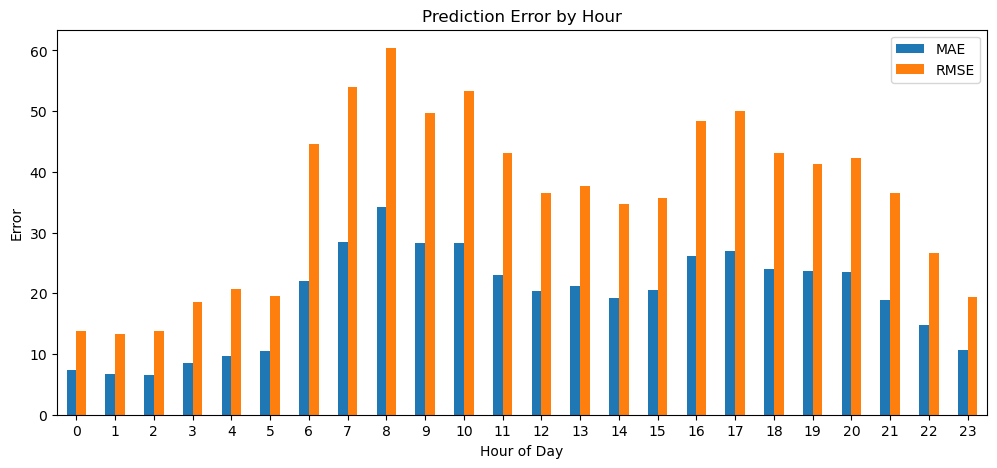

In [41]:
hour_error.plot(
    y=["MAE", "RMSE"],
    kind="bar",
    figsize=(12, 5)
)

plt.title("Prediction Error by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.show()

In [42]:

error_analysis["traffic_change"] = (
    error_analysis["probe_count"]
    - error_analysis["segment_id"].map(

        
        df.set_index(["segment_id", "timestamp"])["probe_count"]
    )
)

In [43]:
change_analysis = test_df[
    ["segment_id", "timestamp", "probe_count", "target_next_hour"]
].copy()

change_analysis["traffic_change"] = (
    change_analysis["target_next_hour"]
    - change_analysis["probe_count"]
)

change_analysis["traffic_change_pct"] = (
    change_analysis["traffic_change"]
    / change_analysis["probe_count"].replace(0, np.nan)
) * 100

change_analysis["absolute_error"] = (
    change_analysis["target_next_hour"] - test_pred
).abs()

change_analysis["abs_change"] = change_analysis["traffic_change"].abs()

change_analysis[
    ["traffic_change", "traffic_change_pct", "absolute_error", "abs_change"]
].describe()

,traffic_change,traffic_change_pct,absolute_error,abs_change
count,1.770598e+06,1.661436e+06,1.770598e+06,1.770598e+06
mean,8.284275e-01,1.340181e+01,1.944582e+01,2.643162e+01
std,5.185373e+01,8.446912e+01,3.326665e+01,4.461911e+01
min,-7.390000e+02,-1.000000e+02,8.463860e-06,0.000000e+00
25%,-1.000000e+01,-2.343750e+01,2.130140e+00,3.000000e+00
50%,0.000000e+00,0.000000e+00,7.420486e+00,1.000000e+01
75%,1.000000e+01,2.625698e+01,2.223485e+01,3.100000e+01
max,1.051000e+03,4.900000e+03,9.094676e+02,1.051000e+03


In [44]:
change_bins = pd.cut(
    change_analysis["abs_change"],
    bins=[-1, 5, 10, 25, 50, 100, 250, 500, float("inf")],
    labels=[
        "0-5",
        "5-10",
        "10-25",
        "25-50",
        "50-100",
        "100-250",
        "250-500",
        "500+"
    ]
)

change_error = (
    change_analysis
    .groupby(change_bins, observed=True)
    .agg(
        samples=("absolute_error", "size"),
        MAE=("absolute_error", "mean"),
        RMSE=("absolute_error", lambda x: np.sqrt(np.mean(x**2))),
        mean_abs_change=("abs_change", "mean")
    )
)

change_error

,samples,MAE,RMSE,mean_abs_change
abs_change,,,,
0-5,659873,3.996716,8.886091,2.003845
5-10,237890,8.565508,13.991904,7.799206
10-25,356206,14.520015,20.746474,16.937707
25-50,247586,26.858833,34.613968,36.114615
50-100,169178,47.063980,57.676386,70.438745
100-250,88783,89.442720,107.236288,145.744591
250-500,10253,177.008704,202.361529,318.985468
500+,829,260.218787,304.275881,627.819059


In [45]:
print(
    "Correlation between absolute traffic change and absolute prediction error:",
    change_analysis["abs_change"].corr(
        change_analysis["absolute_error"]
    )
)

Correlation between absolute traffic change and absolute prediction error: 0.7573854476933587


In [46]:
# Traffic momentum / change features

df["traffic_change_1h"] = (
    df["probe_count"] - df["probe_lag_1"]
)

df["traffic_change_3h"] = (
    df["probe_count"] - df["probe_lag_3"]
)

df["traffic_change_6h"] = (
    df["probe_count"] - df["probe_lag_6"]
)

# Acceleration:
# difference between the latest 1-hour change
# and the previous 1-hour change

df["traffic_acceleration"] = (
    (df["probe_count"] - df["probe_lag_1"])
    - (df["probe_lag_1"] - df["probe_lag_2"])
)

In [47]:
df[
    [
        "probe_count",
        "probe_lag_1",
        "probe_lag_2",
        "traffic_change_1h",
        "traffic_change_3h",
        "traffic_change_6h",
        "traffic_acceleration"
    ]
].describe()

,probe_count,probe_lag_1,probe_lag_2,traffic_change_1h,traffic_change_3h,traffic_change_6h,traffic_acceleration
count,1.197024e+07,1.194530e+07,1.192036e+07,1.194530e+07,1.189543e+07,1.182061e+07,1.192036e+07
mean,1.240317e+02,1.240286e+02,1.239674e+02,6.392588e-02,5.002014e-01,1.467538e+00,-9.407263e-03
std,1.962645e+02,1.963118e+02,1.962755e+02,4.742043e+01,9.908992e+01,1.495149e+02,5.705036e+01
min,0.000000e+00,0.000000e+00,0.000000e+00,-7.890000e+02,-1.310000e+03,-1.801000e+03,-1.324000e+03
25%,9.000000e+00,9.000000e+00,9.000000e+00,-1.000000e+01,-1.800000e+01,-2.900000e+01,-1.000000e+01
50%,4.600000e+01,4.600000e+01,4.600000e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,1.480000e+02,1.480000e+02,1.480000e+02,9.000000e+00,1.800000e+01,3.100000e+01,1.400000e+01
max,2.766000e+03,2.766000e+03,2.766000e+03,1.094000e+03,2.169000e+03,2.554000e+03,1.274000e+03


In [48]:
momentum_features = [
    "probe_count",
    "probe_lag_1",
    "probe_lag_2",
    "probe_lag_3",
    "probe_lag_6",
    "probe_lag_24",
    "rolling_mean_3h",
    "rolling_std_3h",
    "rolling_mean_6h",
    "traffic_change_1h",
    "traffic_change_3h",
    "traffic_change_6h",
    "traffic_acceleration",
    "hour",
    "day_of_week",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos",
    "speed_limit",
    "frc",
    "distance"
]

target_column = "target_next_hour"

df_ml_momentum = df.dropna(
    subset=momentum_features + [target_column]
).copy()

print("Shape:", df_ml_momentum.shape)
print("Missing values:", df_ml_momentum[momentum_features + [target_column]].isna().sum().sum())

Shape: (11346790, 30)
Missing values: 0


In [49]:
train_df_m = df_ml_momentum[
    df_ml_momentum["timestamp"] <= train_end
]

val_df_m = df_ml_momentum[
    (df_ml_momentum["timestamp"] > train_end) &
    (df_ml_momentum["timestamp"] <= val_end)
]

test_df_m = df_ml_momentum[
    df_ml_momentum["timestamp"] > val_end
]

X_train_m = train_df_m[momentum_features]
y_train_m = train_df_m[target_column]

X_val_m = val_df_m[momentum_features]
y_val_m = val_df_m[target_column]

X_test_m = test_df_m[momentum_features]
y_test_m = test_df_m[target_column]

print("Train:", X_train_m.shape)
print("Validation:", X_val_m.shape)
print("Test:", X_test_m.shape)

Train: (7780656, 23)
Validation: (1795536, 23)
Test: (1770598, 23)


In [50]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

momentum_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

momentum_model.fit(
    X_train_m,
    y_train_m,
    eval_set=[(X_val_m, y_val_m)],
    verbose=False
)

momentum_val_pred = momentum_model.predict(X_val_m)
momentum_test_pred = momentum_model.predict(X_test_m)

print("Momentum model")
print(
    "Validation MAE:",
    mean_absolute_error(y_val_m, momentum_val_pred)
)
print(
    "Validation RMSE:",
    np.sqrt(mean_squared_error(y_val_m, momentum_val_pred))
)

print(
    "Test MAE:",
    mean_absolute_error(y_test_m, momentum_test_pred)
)
print(
    "Test RMSE:",
    np.sqrt(mean_squared_error(y_test_m, momentum_test_pred))
)

Momentum model
Validation MAE: 16.823261682274016
Validation RMSE: 33.29870819835396
Test MAE: 19.316819599031806
Test RMSE: 37.92689564016508


In [51]:
importance = (
    pd.Series(
        momentum_model.feature_importances_,
        index=momentum_features
    )
    .sort_values(ascending=False)
)

importance

probe_count             0.789212
probe_lag_24            0.126725
probe_lag_1             0.026729
hour_cos                0.009543
hour_sin                0.007378
hour                    0.005137
traffic_change_1h       0.004878
traffic_change_3h       0.004184
traffic_change_6h       0.002843
rolling_mean_6h         0.002467
is_weekend              0.002464
probe_lag_2             0.002254
frc                     0.002199
speed_limit             0.001984
rolling_mean_3h         0.001777
day_of_week             0.001604
day_cos                 0.001557
probe_lag_3             0.001549
day_sin                 0.001496
probe_lag_6             0.001466
traffic_acceleration    0.001283
rolling_std_3h          0.000969
distance                0.000304
dtype: float32

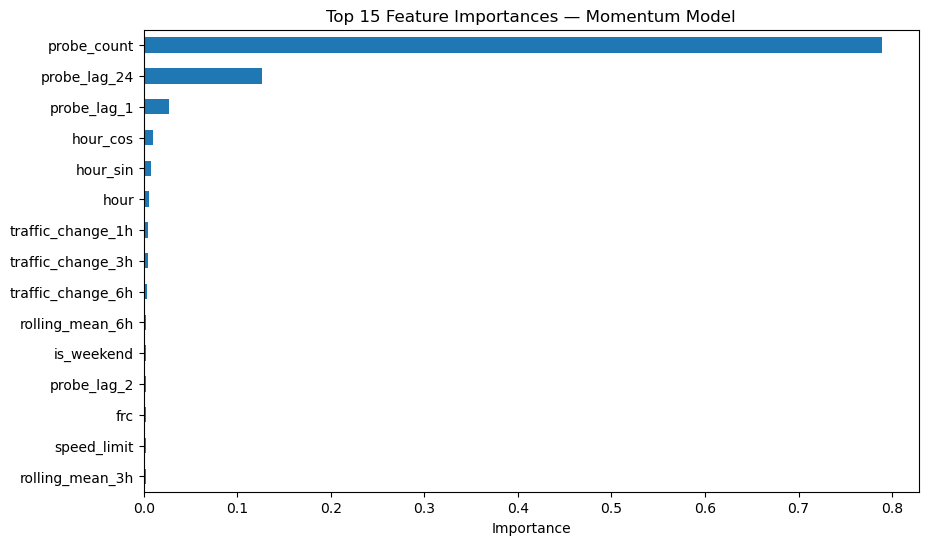

In [52]:
importance.head(15).plot(
    kind="barh",
    figsize=(10, 6)
)

plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances — Momentum Model")
plt.xlabel("Importance")
plt.show()

In [53]:
df["probe_lag_168"] = (
    df.groupby("segment_id")["probe_count"].shift(168)
)

In [54]:
print(
    df["probe_lag_168"].isna().sum()
)

print(
    df[["probe_count", "probe_lag_24", "probe_lag_168"]].describe()
)

4189584
        probe_count  probe_lag_24  probe_lag_168
count  1.197024e+07  1.137173e+07   7.780656e+06
mean   1.240317e+02  1.232716e+02   1.212696e+02
std    1.962645e+02  1.953801e+02   1.930736e+02
min    0.000000e+00  0.000000e+00   0.000000e+00
25%    9.000000e+00  9.000000e+00   9.000000e+00
50%    4.600000e+01  4.500000e+01   4.400000e+01
75%    1.480000e+02  1.470000e+02   1.440000e+02
max    2.766000e+03  2.766000e+03   2.766000e+03


In [55]:
weekly_features = momentum_features + ["probe_lag_168"]

df_ml_weekly = df.dropna(
    subset=weekly_features + [target_column]
).copy()

print("Shape:", df_ml_weekly.shape)
print(
    "Time range:",
    df_ml_weekly["timestamp"].min(),
    "→",
    df_ml_weekly["timestamp"].max()
)
print(
    "Roads:",
    df_ml_weekly["segment_id"].nunique()
)

Shape: (7755718, 31)
Time range: 2024-08-18 00:00:00 → 2024-08-30 22:00:00
Roads: 24938


In [56]:
# Same chronological split for the weekly-lag experiment

train_df_w = df_ml_weekly[
    df_ml_weekly["timestamp"] <= train_end
].copy()

val_df_w = df_ml_weekly[
    (df_ml_weekly["timestamp"] > train_end) &
    (df_ml_weekly["timestamp"] <= val_end)
].copy()

test_df_w = df_ml_weekly[
    df_ml_weekly["timestamp"] > val_end
].copy()

X_train_w = train_df_w[weekly_features]
y_train_w = train_df_w[target_column]

X_val_w = val_df_w[weekly_features]
y_val_w = val_df_w[target_column]

X_test_w = test_df_w[weekly_features]
y_test_w = test_df_w[target_column]

print("Train:", X_train_w.shape)
print("Validation:", X_val_w.shape)
print("Test:", X_test_w.shape)

print(
    "\nTime ranges:"
)
print("Train:", train_df_w["timestamp"].min(), "→", train_df_w["timestamp"].max())
print("Val:", val_df_w["timestamp"].min(), "→", val_df_w["timestamp"].max())
print("Test:", test_df_w["timestamp"].min(), "→", test_df_w["timestamp"].max())

Train: (4189584, 24)
Validation: (1795536, 24)
Test: (1770598, 24)

Time ranges:
Train: 2024-08-18 00:00:00 → 2024-08-24 23:00:00
Val: 2024-08-25 00:00:00 → 2024-08-27 23:00:00
Test: 2024-08-28 00:00:00 → 2024-08-30 22:00:00


In [57]:
weekly_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

weekly_model.fit(
    X_train_w,
    y_train_w,
    eval_set=[(X_val_w, y_val_w)],
    verbose=False
)

weekly_val_pred = weekly_model.predict(X_val_w)
weekly_test_pred = weekly_model.predict(X_test_w)

print("Weekly-lag model")
print(
    "Validation MAE:",
    mean_absolute_error(y_val_w, weekly_val_pred)
)
print(
    "Validation RMSE:",
    np.sqrt(mean_squared_error(y_val_w, weekly_val_pred))
)

print(
    "Test MAE:",
    mean_absolute_error(y_test_w, weekly_test_pred)
)
print(
    "Test RMSE:",
    np.sqrt(mean_squared_error(y_test_w, weekly_test_pred))
)

Weekly-lag model
Validation MAE: 17.837024265929323
Validation RMSE: 35.67863281848641
Test MAE: 19.971830375545437
Test RMSE: 40.68116425512503


In [58]:
final_candidate_features = [
    "probe_count",
    "probe_lag_1",
    "probe_lag_2",
    "probe_lag_3",
    "probe_lag_6",
    "probe_lag_24",
    "rolling_mean_3h",
    "rolling_std_3h",
    "rolling_mean_6h",
    "traffic_change_1h",
    "traffic_change_3h",
    "traffic_change_6h",
    "traffic_acceleration",
    "hour",
    "day_of_week",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos",
    "speed_limit",
    "frc",
    "distance"
]

print("Number of features:", len(final_candidate_features))
print("Contains lag_168:", "probe_lag_168" in final_candidate_features)

Number of features: 23
Contains lag_168: False


In [59]:
df_ml_log = df.dropna(
    subset=final_candidate_features + [target_column]
).copy()

df_ml_log["target_log"] = np.log1p(
    df_ml_log[target_column]
)

print("Shape:", df_ml_log.shape)

Shape: (11346790, 32)


In [60]:
train_df_log = df_ml_log[
    df_ml_log["timestamp"] <= train_end
].copy()

val_df_log = df_ml_log[
    (df_ml_log["timestamp"] > train_end) &
    (df_ml_log["timestamp"] <= val_end)
].copy()

test_df_log = df_ml_log[
    df_ml_log["timestamp"] > val_end
].copy()

X_train_log = train_df_log[final_candidate_features]
X_val_log = val_df_log[final_candidate_features]
X_test_log = test_df_log[final_candidate_features]

y_train_log = train_df_log["target_log"]
y_val_log = val_df_log["target_log"]

# Keep the actual target on the original scale for evaluation
y_test_log = test_df_log[target_column]

print("Train:", X_train_log.shape)
print("Validation:", X_val_log.shape)
print("Test:", X_test_log.shape)

Train: (7780656, 23)
Validation: (1795536, 23)
Test: (1770598, 23)


In [61]:
log_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

log_model.fit(
    X_train_log,
    y_train_log,
    eval_set=[(X_val_log, y_val_log)],
    verbose=False
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [62]:
log_val_pred = np.expm1(
    log_model.predict(X_val_log)
)

log_test_pred = np.expm1(
    log_model.predict(X_test_log)
)

log_val_pred = np.maximum(log_val_pred, 0)
log_test_pred = np.maximum(log_test_pred, 0)

In [63]:
print("Log-target model")

print(
    "Validation MAE:",
    mean_absolute_error(
        val_df_log[target_column],
        log_val_pred
    )
)

print(
    "Validation RMSE:",
    np.sqrt(
        mean_squared_error(
            val_df_log[target_column],
            log_val_pred
        )
    )
)

print(
    "Test MAE:",
    mean_absolute_error(
        test_df_log[target_column],
        log_test_pred
    )
)

print(
    "Test RMSE:",
    np.sqrt(
        mean_squared_error(
            test_df_log[target_column],
            log_test_pred
        )
    )
)

Log-target model
Validation MAE: 16.69256127835004
Validation RMSE: 33.547019745309186
Test MAE: 19.480907019523094
Test RMSE: 39.31293881204284


In [64]:
from sklearn.metrics import r2_score

final_test_pred = momentum_test_pred

print("Final Model Performance")
print("-----------------------")

print(
    "MAE:",
    mean_absolute_error(y_test_m, final_test_pred)
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(y_test_m, final_test_pred)
    )
)

print(
    "R²:",
    r2_score(y_test_m, final_test_pred)
)

Final Model Performance
-----------------------
MAE: 19.316819599031806
RMSE: 37.92689564016508
R²: 0.9654145586590792


In [65]:
final_results = test_df_m[
    [
        "segment_id",
        "timestamp",
        "probe_count",
        "target_next_hour"
    ]
].copy()

final_results["prediction"] = final_test_pred

final_results["absolute_error"] = (
    final_results["target_next_hour"]
    - final_results["prediction"]
).abs()

final_results["signed_error"] = (
    final_results["target_next_hour"]
    - final_results["prediction"]
)

final_results.head()

,segment_id,timestamp,probe_count,target_next_hour,prediction,absolute_error,signed_error
408,-13560345653226,2024-08-28 00:00:00,0,0.0,-0.261311,0.261311,0.261311
409,-13560345653226,2024-08-28 01:00:00,0,0.0,-0.335296,0.335296,0.335296
410,-13560345653226,2024-08-28 02:00:00,0,0.0,-0.290367,0.290367,0.290367
411,-13560345653226,2024-08-28 03:00:00,0,0.0,0.153431,0.153431,-0.153431
412,-13560345653226,2024-08-28 04:00:00,0,0.0,0.418934,0.418934,-0.418934


In [66]:
# Enforce the valid domain of traffic counts
final_test_pred_clipped = np.maximum(final_test_pred, 0)

print("Final Model Performance — Clipped Predictions")
print("-----------------------------------------------")

print(
    "MAE:",
    mean_absolute_error(y_test_m, final_test_pred_clipped)
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(y_test_m, final_test_pred_clipped)
    )
)

print(
    "R²:",
    r2_score(y_test_m, final_test_pred_clipped)
)

print(
    "Negative predictions before clipping:",
    (final_test_pred < 0).sum()
)

print(
    "Negative predictions after clipping:",
    (final_test_pred_clipped < 0).sum()
)

Final Model Performance — Clipped Predictions
-----------------------------------------------
MAE: 19.309116279822717
RMSE: 37.926772696341395
R²: 0.9654147828830468
Negative predictions before clipping: 32766
Negative predictions after clipping: 0


In [67]:
# Final predictions should always use the clipped version
final_test_pred = final_test_pred_clipped

# Update final results with production-valid predictions
final_results["prediction"] = final_test_pred

# Recalculate errors
final_results["absolute_error"] = (
    final_results["target_next_hour"]
    - final_results["prediction"]
).abs()

final_results["signed_error"] = (
    final_results["target_next_hour"]
    - final_results["prediction"]
)

print("Final results shape:", final_results.shape)
print(final_results.head())

Final results shape: (1770598, 7)
         segment_id           timestamp  probe_count  target_next_hour  \
408 -13560345653226 2024-08-28 00:00:00            0               0.0   
409 -13560345653226 2024-08-28 01:00:00            0               0.0   
410 -13560345653226 2024-08-28 02:00:00            0               0.0   
411 -13560345653226 2024-08-28 03:00:00            0               0.0   
412 -13560345653226 2024-08-28 04:00:00            0               0.0   

     prediction  absolute_error  signed_error  
408    0.000000        0.000000      0.000000  
409    0.000000        0.000000      0.000000  
410    0.000000        0.000000      0.000000  
411    0.153431        0.153431     -0.153431  
412    0.418934        0.418934     -0.418934  


In [68]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


In [69]:
import shap

In [70]:
X_shap = X_test_m.sample(
    n=5000,
    random_state=42
)

print("SHAP sample shape:", X_shap.shape)

SHAP sample shape: (5000, 23)


In [71]:
%pip install --upgrade shap

Note: you may need to restart the kernel to use updated packages.


In [72]:
import xgboost
import shap

print("XGBoost:", xgboost.__version__)
print("SHAP:", shap.__version__)

XGBoost: 3.2.0
SHAP: 0.49.1


In [73]:
from pathlib import Path
import json

MODEL_DIR = Path("../src/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# 1. Save XGBoost model
momentum_model.save_model(MODEL_DIR / "traffic_forecaster.json")

# 2. Save exact feature order
with open(MODEL_DIR / "feature_columns.json", "w") as f:
    json.dump(final_candidate_features, f, indent=2)

# 3. Save model metadata
model_metadata = {
    "model_type": "XGBoost Regressor",
    "target": "next_hour_probe_count",
    "forecast_horizon_hours": 1,
    "features": final_candidate_features,
    "n_features": len(final_candidate_features),
    "test_mae": 19.309116279822717,
    "test_rmse": 37.926772696341395,
    "test_r2": 0.9654147828830468,
    "negative_predictions_clipped": True
}

with open(MODEL_DIR / "model_metadata.json", "w") as f:
    json.dump(model_metadata, f, indent=2)

print("Model artifacts saved successfully:")
for file in MODEL_DIR.iterdir():
    print(" -", file.name)

Model artifacts saved successfully:
 - traffic_forecaster.json
 - model_metadata.json
 - feature_columns.json


In [74]:
from xgboost import XGBRegressor
import json
import numpy as np
from pathlib import Path

MODEL_DIR = Path("../src/models")

# Load model
loaded_model = XGBRegressor()
loaded_model.load_model(MODEL_DIR / "traffic_forecaster.json")

# Load feature list
with open(MODEL_DIR / "feature_columns.json", "r") as f:
    loaded_features = json.load(f)

print("Model loaded successfully")
print("Number of features:", len(loaded_features))
print("Features match:", loaded_features == final_candidate_features)

Model loaded successfully
Number of features: 23
Features match: True


In [75]:
# Take a small sample from the test set
X_check = X_test_m.iloc[:10]

original_predictions = momentum_model.predict(X_check)
loaded_predictions = loaded_model.predict(X_check)

print("Original predictions:")
print(original_predictions)

print("\nLoaded predictions:")
print(loaded_predictions)

print(
    "\nPredictions identical:",
    np.allclose(original_predictions, loaded_predictions)
)

Original predictions:
[-0.2613107  -0.33529618 -0.29036656  0.15343075  0.41893438  1.4435254
  2.124276    2.4165885   2.0156627   1.5531601 ]

Loaded predictions:
[-0.2613107  -0.33529618 -0.29036656  0.15343075  0.41893438  1.4435254
  2.124276    2.4165885   2.0156627   1.5531601 ]

Predictions identical: True


In [76]:
# Pick one real test observation
sample_row = test_df_m.iloc[0]

sample_row[final_candidate_features]

probe_count                    0
probe_lag_1                  1.0
probe_lag_2                  0.0
probe_lag_3                  0.0
probe_lag_6                  0.0
probe_lag_24                 0.0
rolling_mean_3h         0.333333
rolling_std_3h           0.57735
rolling_mean_6h         0.166667
traffic_change_1h           -1.0
traffic_change_3h            0.0
traffic_change_6h            0.0
traffic_acceleration        -2.0
hour                           0
day_of_week                    2
is_weekend                     0
hour_sin                     0.0
hour_cos                     1.0
day_sin                 0.974928
day_cos                -0.222521
speed_limit                   28
frc                            2
distance                    6.88
Name: 408, dtype: object

In [77]:
api_test_prediction = momentum_model.predict(
    test_df_m.iloc[[0]][final_candidate_features]
)[0]

api_test_prediction = max(float(api_test_prediction), 0.0)

print("Notebook prediction:", api_test_prediction)

Notebook prediction: 0.0
